In [1]:
import pandas as pd
import sys
import warnings
warnings.filterwarnings('ignore')

# Ajout du dossier 'src' au chemin (path) pour importer vos modules locaux
sys.path.append('../src')

# Importation de vos propres modules
import utils
import preprocessing

In [ ]:
data_path = '../data/raw/data.csv'
df_raw = pd.read_csv(data_path)

print(f"Dimensions du dataset brut : {df_raw.shape}")
df_raw.head()

Dimensions du dataset brut : (4372, 52)


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


In [4]:
print("=== ÉTAT DES DONNÉES AVANT NETTOYAGE ===")

# 1. Affichage des valeurs manquantes
missing_before = utils.display_missing_values(df_raw, threshold=0.0)

# 2. Statistiques descriptives
utils.display_basic_stats(df_raw)

# 3. Distribution de la variable cible 'Churn'
if 'Churn' in df_raw.columns:
    utils.display_class_distribution(df_raw['Churn'], label="Churn")

=== ÉTAT DES DONNÉES AVANT NETTOYAGE ===

[utils] Taux de valeurs manquantes (seuil > 0%) :
Age                        30.0%
AvgDaysBetweenPurchases     1.8%

[utils] Statistiques descriptives :
                            count          mean          std            min           25%           50%           75%            max
CustomerID                 4372.0  15299.677722  1722.390705   12346.000000  13812.750000  15300.500000  16778.250000   18287.000000
Recency                    4372.0     92.047118   100.765435       1.000000     17.000000     50.000000    143.000000     374.000000
Frequency                  4372.0      5.075480     9.338754       1.000000      1.000000      3.000000      5.000000     248.000000
MonetaryTotal              4372.0   1898.459701  8219.345141   -4287.630000    293.362500    648.075000   1611.725000  279489.020000
MonetaryAvg                4372.0     28.839013   127.323926   -4287.630000     10.985960     16.918616     23.542941    3861.000000
Monetar

=== MATRICE DE CORRÉLATION (AVANT NETTOYAGE) ===


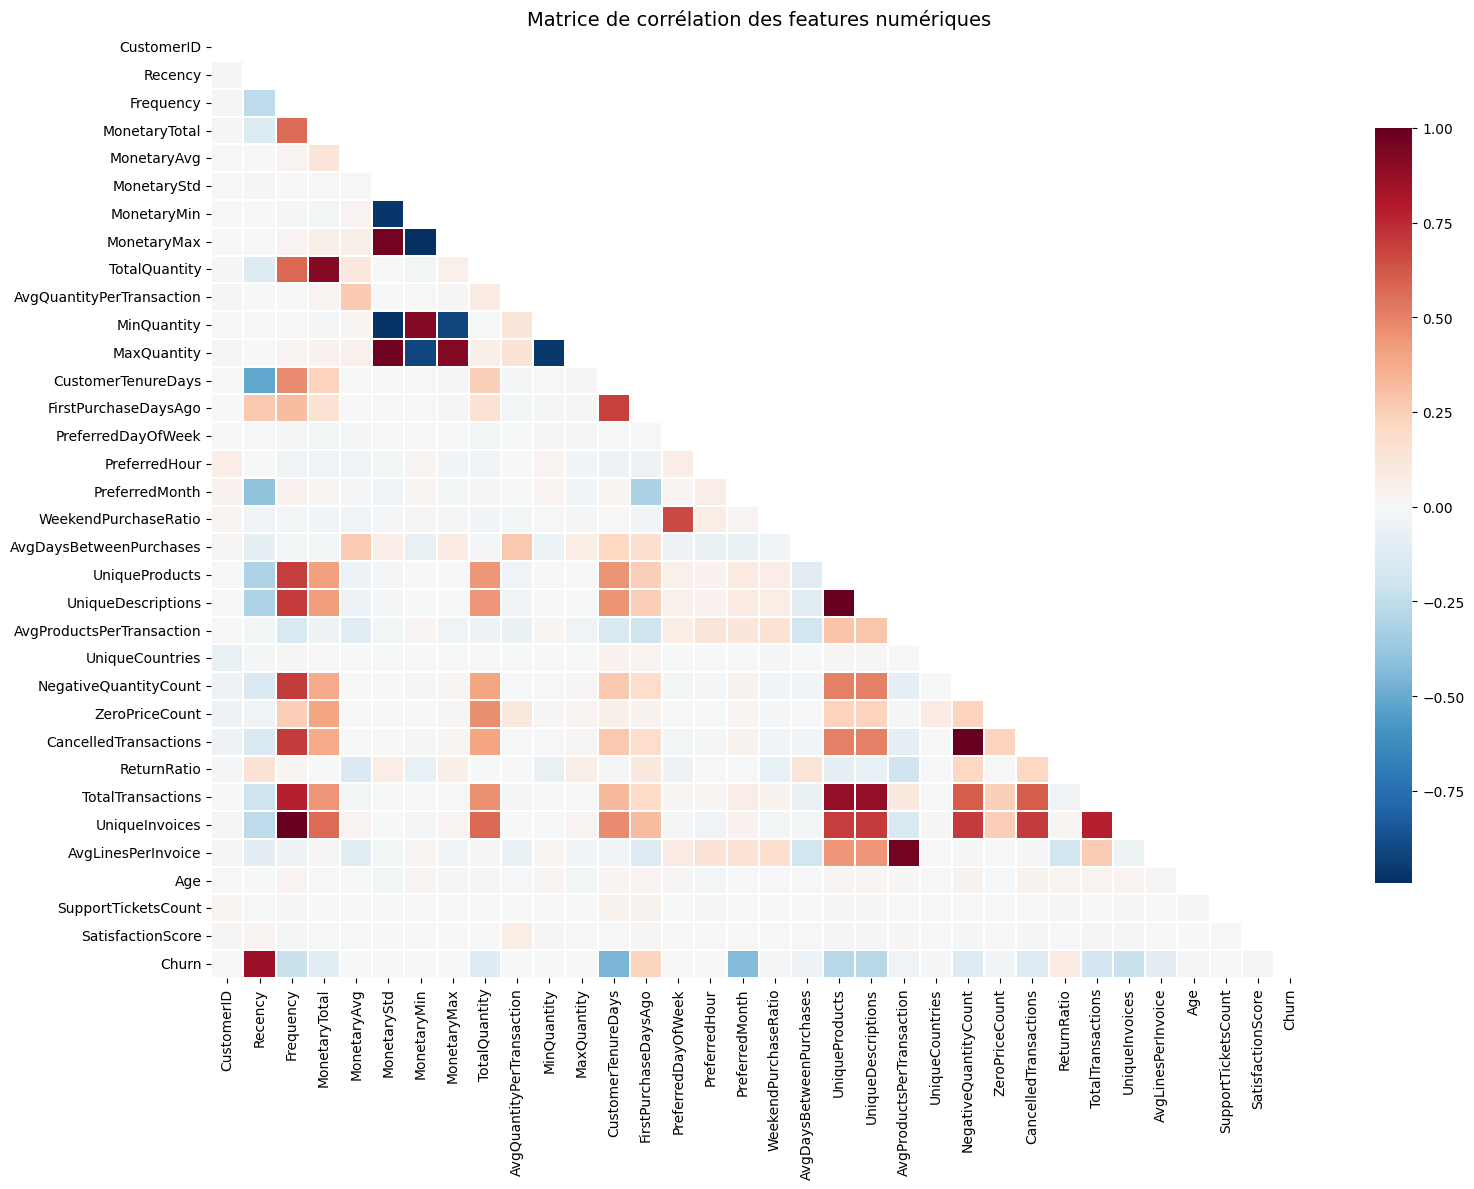

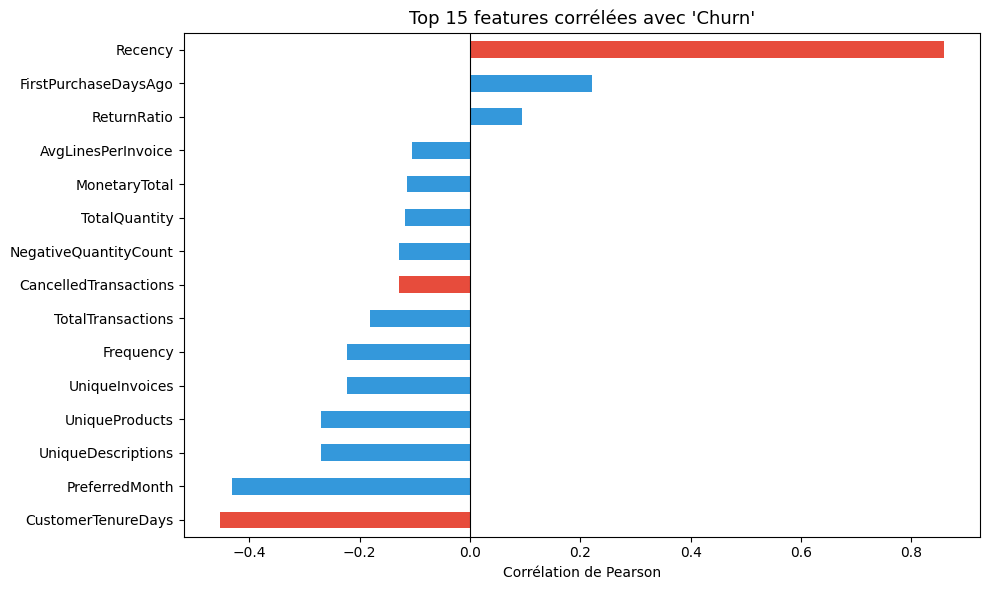

In [5]:
print("=== MATRICE DE CORRÉLATION (AVANT NETTOYAGE) ===")

# 1. Heatmap globale de corrélation
corr_matrix_before = utils.plot_correlation_heatmap(df_raw, target="Churn", figsize=(16, 12))

# 2. Top des features les plus corrélées au Churn
if 'Churn' in df_raw.columns:
    utils.plot_churn_correlations(df_raw, target="Churn", top_n=15)